# Advances of the Project

## Title / Objective:
Reproducible Analysis of CMS Open Data: Search for Dark Matter in Association with Top Quarks
(Based on the CMS publication: “Search for dark matter produced in association with a single top quark or a top quark pair in proton–proton collisions at ($\sqrt s = 13 \TeV$”).

# Physics Motivation

The Large Hadron Collider (LHC) operates at center-of-mass energies sufficient to probe physics beyond the Standard Model (BSM). A primary goal of the LHC program is to identify the nature of **Dark Matter (DM)**. In many simplified models, DM candidates ($\chi$) interact with Standard Model particles via a new mediator ($\phi$ or $a$). Since these mediators often couple to mass (Yukawa-like coupling), the **top quark**—being the heaviest elementary particle—offers the most sensitive probe for direct DM production.


At the parton level, the interaction produces top quarks accompanied by a mediator, which subsequently decays into a pair of invisible DM particles ($\chi\bar{\chi}$). This results in a final state characterized by heavy flavor quarks and significant **Missing Transverse Momentum ($p_T^{\text{miss}}$)** due to the invisible particles.

The dominant production mechanisms considered are:

* **Gluon Fusion ($t\bar{t}$+DM):**
    $$gg \to t \bar{t}\,\phi \to t \bar{t} + \chi \bar{\chi}$$

* **Single Top Associated Production ($tW$+DM):**
    $$gb \to t W \phi \to t W + \chi \bar{\chi}$$

* **t-channel Production ($tj$+DM):**
    $$qq' \to t j \phi \to t j + \chi \bar{\chi}$$

###  From Partons to Detector Signatures

The experimental signature is determined by the decay of the top quarks ($t \to W b$). The $W$ boson decays either hadronically ($W \to q\bar{q}'$, BR $\approx 67\%$) or leptonically ($W \to \ell \nu$, BR $\approx 33\%$). Consequently, the analysis is categorized into orthogonal **channels** based on the number of isolated charged leptons ($e, \mu$) in the final state:

* **All-Hadronic (AH) Channel (0 leptons):**
    * *Signature:* Multiple jets, b-tags, and large $p_T^{\text{miss}}$.
    * *Pros/Cons:* Highest signal yield, but suffers from overwhelming QCD multijet background and difficult trigger thresholds.

* **Single-Lepton (SL) Channel (1 lepton):**
    * *Signature:* Exactly one isolated lepton, jets, b-tags, and $p_T^{\text{miss}}$.
    * *Pros/Cons:* The "Golden Channel." It offers an optimal balance, suppressing QCD significantly while retaining higher statistics than the dilepton channel.

* **Dilepton (DL) Channel (2 leptons):**
    * *Signature:* Two opposite-sign leptons, jets, and $p_T^{\text{miss}}$.
    * *Pros/Cons:* Cleanest signal region with very low background, but statistically limited by the low branching fraction.

### The Single-Muon Channel

In this workflow, we focus exclusively on the **Single-Muon ($1\mu$) channel**.

This choice is driven by both physics and pedagogical clarity. Experimentally, muons provide a cleaner signature than electrons in the CMS detector, with lower bremsstrahlung rates and robust identification efficiencies. By requiring exactly one high-$p_T$ muon, we can effectively eliminate the QCD background, leaving **$t\bar{t}$+Jets** and **$W$+Jets** as the primary backgrounds to model.

This strategy allows us to demonstrate a complete End-to-End analysis—from object selection to statistical interpretation—in a controlled environment where the interplay between the DM signal (high $p_T^{\text{miss}}$) and Standard Model backgrounds can be clearly studied.

After defining the objective of the project (Reproducible Analysis of CMS Open Data), we discussed in which data format to work — NanoAOD or MiniAOD. We decided to use NanoAOD, because it is lighter and optimized for analysis tasks.

In the most precise version, we work within cernbox/swan, but it can work in any Jupyter environment; the important packages are: uproot and awkward

## Single Lepton

by B.V

We import all the libraries that we are going to use.

In [98]:

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hist


import requests
import os
import time
import json


import awkward as ak
import uproot
import vector
vector.register_awkward()




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We will use the **dpoa_workshop_utilities** module to help you access the datasets. The functions it contains are:


The `nanoaod_filenames` is a dictionary with the urls to the file indexes of the root files for every dataset that we will use in the analysis.

The `pretty_print(fields, fmt='40s', require=None, ignore=None)` function allows you to print subsets of keys based on strings that you require or ignore. It will also format that output based on how many characters you want in a column (you are limited to 80 characters per line).

The `build_lumi_mask(lumifile, tree, verbose=False)` function helps you mask (select) the data that's collected from collisions.

In [99]:

#-------------------------------

import dpoa_workshop
from dpoa_workshop import (
    nanoaod_filenames,
    get_files_for_dataset,
    pretty_print,
    build_lumi_mask
)
#-------------------------------------------


In the drafts related to the papers, the datasets used from 2016 are listed along with their run periods and corresponding luminosities. However, one must be careful with these values, because not all periods are available and the data format differs from the one originally used, as previously noted.”

# Building the Ntuple File Index

CMS Open Data provides **file index text files** (`file_index.txt`) for each dataset.  
These contain the actual XRootD paths to the NanoAOD `.root` files, along with metadata such as the number of events per file. Example line:

root://eospublic.cern.ch//eos/opendata/cms/mc/.../nano_1.root nevts=58293


The objective is to collect file paths from multiple URLs, organize them by dataset, and store them in a JSON file, while handling possible download errors so the program keeps running.


### To streamline the workflow:
- We define a function `download_files(url)` that fetches each `file_index.txt` via HTTP and extracts only the ROOT file paths.  
- We loop over all entries in `nanoaod_filenames` (the dictionary we built earlier) and collect the full list of ROOT files per dataset.  
- The result is stored in a new dictionary `ntuples`, which maps *dataset -- list of ROOT file paths*.  
- Finally, we save this as a JSON file (`ntuples.json`) for later reuse

In [100]:

#import requests
#import json

def download_files(url):
    r = requests.get(url)
    lines = [ln.strip() for ln in r.text.splitlines() if ln.strip()]
    paths = [ln.split()[0] for ln in lines]
    return paths

ntuples = {}

print(f"{'Dataset':<30} | {'Part':<5} | {'Files'}")
print("-" * 50)

for dataset, urls in nanoaod_filenames.items():
    all_paths = []
    for i, url in enumerate(urls):
        try:
            paths = download_files(url)
            
            print(f"{dataset[:30]:<30} | {i:<5} | {len(paths)}")
            
            all_paths.extend(paths)
        except Exception as e:
            print(f"[warn] {dataset} {url}--{e}")
            
    ntuples[dataset] = all_paths

with open("ntuples.json", "w") as f:
    json.dump(ntuples, f, indent=2)

print("-" * 50)
print("ntuples.json creado. Keys:", list(ntuples.keys()))


Dataset                        | Part  | Files
--------------------------------------------------
met                            | 0     | 7
met                            | 1     | 4
met                            | 2     | 21
SingleMuon                     | 0     | 1
SingleMuon                     | 1     | 1
SingleMuon                     | 2     | 40
SingleMuon                     | 3     | 8
SingleMuon                     | 4     | 32
SingleElectron                 | 0     | 6
SingleElectron                 | 1     | 20
SingleElectron                 | 2     | 11
SingleElectron                 | 3     | 43
ttbar-semileptonic             | 0     | 41
ttbar-semileptonic             | 1     | 26
ttbar-semileptonic             | 2     | 23
ttbar-semileptonic             | 3     | 21
ttbar-semileptonic             | 4     | 27
t-channel-top                  | 0     | 4
t-channel-top                  | 1     | 4
t-channel-top                  | 2     | 5
t-channel-top                  


Since `ntuples.json` concatenates all files into a single flat list per dataset, the distinction between source URLs (which often represent different periods like **Run2016G** vs **Run2016H**) is lost in the final file.

**Why counting matters:**
By logging the number of files in each part (`len(paths)`), we establish a **positional map**:
1.  It helps us identify which specific period a root file belongs to based on its index in the merged list.
2.  It ensures we can verify that the total file count matches the sum of the individual periods (sanity check).

And we will download important files like the luminosity file.

In [101]:

!wget https://opendata.cern.ch/record/14220/files/Cert_271036-284044_13TeV_Legacy2016_Collisions16_JSON.txt



--2026-03-19 21:10:59--  https://opendata.cern.ch/record/14220/files/Cert_271036-284044_13TeV_Legacy2016_Collisions16_JSON.txt
Resolving opendata.cern.ch (opendata.cern.ch)... 137.138.6.31, 2001:1458:201:8b::100:1c8
Connecting to opendata.cern.ch (opendata.cern.ch)|137.138.6.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11686 (11K) [text/plain]
Saving to: ‘Cert_271036-284044_13TeV_Legacy2016_Collisions16_JSON.txt.3’

Cert_271036-284044_ 100%[===================>]  11.41K  --.-KB/s    in 0.001s  

2026-03-19 21:10:59 (15.3 MB/s) - ‘Cert_271036-284044_13TeV_Legacy2016_Collisions16_JSON.txt.3’ saved [11686/11686]



In [102]:


XSEC2_PB = {

    
    ##### TOP QUARK #############
    "ttbar-semileptonic": 364.35,  
    "t-channel-top": 136.02,       # ST t-channel top
    "t-channel-antitop": 80.95,    # ST t-channel antitop
    "tW-top": 35.85,               # ST tW top 
    
    #### Rare Top 
    "ttW": 0.2043,  #  to TTWJetsToLNu
    "ttZ": 0.2529,  # to TTZToLLNuNu
    
    ##### WJETS (HT Binned) 
    
    "WJets-HT70to100":    1372.0,
    "WJets-HT100to200":   1345.0, # (Check this value, it seems high to be binned, maybe it's LO)
    "WJets-HT200to400":   359.7,  
    "WJets-HT400to600":   48.91,  
    "WJets-HT600to800":   12.05,
    "WJets-HT800to1200":  5.501,  
    "WJets-HT1200to2500": 1.329,  
    "WJets-HT2500toInf":  0.0322,

    #######DRELL-YAN (DY)
    "DYJets-HT100to200": 147.40,
    "DYJets-HT200to400": 40.99,
    "DYJets-HT400to600": 5.678,
    
    ##### DIBOSON 
    "WW": 118.7, 
    "ZZ": 16.6,   
    "WZ": 47.13  
}


until while these datasets are being used

In [103]:

XSEC_PB = {
        
    ##### Top Quark
    "ttbar-semileptonic": 364.35,   
    "t-channel-top":      136.02, 
    "t-channel-antitop": 80.95,
    "ttW":                0.2043,   

    ##### WJets 
    "WJets-HT70to100":    1372.0,
    "WJets-HT100to200":   1345.0,    
    "WJets-HT200to400":  359.7 , ## in data , wrong   
    "WJets-HT400to600":   48.91, 

    # --- Electroweak / Bosons ---
    "DYJets-Zpt200":      1.27,     
    "WW":                 118.7,    
    "ZZ":                 16.6,     
    "Zvv":                77.3,     
}



---

This function builds the fileset used by the analysis. It reads the JSON inventory of ntuples, identifies which samples are data or MC, applies an optional file limit for fast debugging, and attaches minimal metadata such as the cross section and number of files. The output is a clean, ready-to-use dictionary that tells the processor exactly which datasets to run over and how they should be treated.

In [104]:

def construct_fileset(ntuples_json="ntuples.json", limit=None, verbose=True):
    """
    Parses the input JSON inventory and assigns metadata (xsec, is_data).
    
    Args:
        ntuples_json (str): Path to the JSON file containing the file lists.
        limit (int or None): Max number of files to load per process. 
                             Useful for quick debugging (e.g., limit=1).
                             If None, loads all files (production mode).
        verbose (bool): If True, prints a summary table of loaded samples.
    
    Returns:
        dict: A dictionary structured for the processor (Coffea/UpRoot).
    """
    
    with open(ntuples_json) as f:
        info = json.load(f)

    fileset = {}
    
    if verbose:
        print(f"\n{'Name':30} {'Type':>6} {'N Files':>10} {'XSEC [pb]':>12}")
        print("-" * 65)

    for process_name, file_list in info.items():
        
        # Slicing handles None gracefully, but explicit check is clearer for readers
        if limit is not None:
            files_to_use = file_list[:limit]
        else:
            files_to_use = file_list

        #  IDENTIFY TYPE (DATA vs MC) 
        
        if process_name in XSEC_PB:
            is_data = False
            xsec_value = XSEC_PB[process_name]
            proc_type = "MC"
        else:
            is_data = True
            xsec_value = None  # Real data has no theoretical xsec here
            proc_type = "DATA"

        #### BUILD DICTIONARY 
        # Minimal metadata structure to keep it lightweight

        
        fileset[process_name] = {
            "files": files_to_use,
            "metadata": {
                "is_data": is_data,
                "xsec": xsec_value,
                "n_files_loaded": len(files_to_use)
            }
        }

        #  LOGGING ---
        if verbose:
            xsec_str = f"{xsec_value:.2f}" if xsec_value else "-"
            print(f"{process_name:30} {proc_type:>6} {len(files_to_use):>10} {xsec_str:>12}")
    
    return fileset


This line initializes the full list of datasets for the analysis. It loads all ntuples defined in *ntuples.json* (since `limit=None`) and prints a summary of the samples. The resulting `fileset` becomes the central input that tells the processor which data and MC files to process.

In [105]:

fileset = construct_fileset(
    ntuples_json="ntuples.json",
    limit=None,      
    verbose=True
)



Name                             Type    N Files    XSEC [pb]
-----------------------------------------------------------------
met                              DATA         32            -
SingleMuon                       DATA         82            -
SingleElectron                   DATA         80            -
ttbar-semileptonic                 MC        138       364.35
t-channel-top                      MC         25       136.02
t-channel-antitop                  MC         13        80.95
ttW                                MC         12         0.20
WJets-HT400to600                   MC         11        48.91
WJets-HT100to200                   MC         20      1345.00
WJets-HT200to400                   MC         60       359.70
WJets-HT70to100                    MC         19      1372.00
DYJets-Zpt200                      MC         10         1.27
WW                                 MC         41       118.70
ZZ                                 MC         17        16.60
Zvv

In [127]:

dataset = "met" ##just for training

for i, fpath in enumerate(fileset[dataset]["files"][:10]):
    print(f"{i+1:2d}. {fpath}")



 1. root://eospublic.cern.ch//eos/opendata/cms/Run2016H/MET/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/120000/16D21B45-0388-FF40-8872-B398D762F652.root
 2. root://eospublic.cern.ch//eos/opendata/cms/Run2016H/MET/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/120000/2F8F8158-EA07-8941-A37E-667E096ADD52.root
 3. root://eospublic.cern.ch//eos/opendata/cms/Run2016H/MET/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/120000/50BD6B95-B1F7-2B47-832F-4DE7F49D0D5C.root
 4. root://eospublic.cern.ch//eos/opendata/cms/Run2016H/MET/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/120000/5F1C5DD5-A4DD-4D46-A97D-6A5B987FA8A9.root
 5. root://eospublic.cern.ch//eos/opendata/cms/Run2016H/MET/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/120000/D30D02C2-C90F-2C4F-9541-D07EC52F79C9.root
 6. root://eospublic.cern.ch//eos/opendata/cms/Run2016H/MET/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/120000/DFE14C99-E541-7845-8492-714D4F657B15.root
 7. root://eospublic.cern.ch//eos/opendata/cms/Run2016H/MET/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/120000/E9959B82-5EBA

In [128]:

#import uproot

sample = "ttbar-semileptonic"

root_path = fileset[sample]["files"][0]
print("Open:", root_path)

f = uproot.open(root_path)
events = f["Events"]

print("# events:", events.num_entries)

all_keys = events.keys()
print(f"Total braches : {len(all_keys)}")



Open: root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/120000/08FCB2ED-176B-064B-85AB-37B898773B98.root
# events: 1233000
Total braches : 1504


In [129]:

if "genWeight" in events.keys():
    gw = events["genWeight"].array(entry_stop=100_000, library="np")
    print(f"genWeight: mean={gw.mean():.3f}, std={gw.std():.3f}, negativos={(gw<0).mean():.2%}")
else:
    print("There is no genWeight")



genWeight: mean=300.828, std=39.097, negativos=0.42%


    genWeight: mean=300.828, std=39.097, negativos=0.42%


Because std > 0 and negativos > 0, you have learned a golden rule for this dataset:

NEVER count events.

Wrong: N = len(events)

Right: N = sum(events.genWeight)

If you just count them (len), you will be wrong by 0.84% (counting the negatives as positives instead of subtracting them).

---
## "Having defined the dataset, we move to data processing. Since the reference analysis has already optimized the kinematic variables, we will adopt their final cuts directly. We will retrieve these specific thresholds from the summary tables and apply the necessary selection techniques to our data."
---



**The workflow proceeds in three main steps:**

1. **Apply the baseline selection**
   We first select events that match the single-lepton topology (electron or muon).
   This removes events that clearly do not belong to the channel and defines the core event structure we will work with.

2. **Filter the events**
   After the baseline, we keep only the events that satisfy these basic criteria.
   This produces a clean and well-defined sample for further analysis.

3. **Apply additional cuts to build CR and SR**
   With the filtered sample, we introduce extra requirements to define:

   * **Control Regions (CR):** used to study and validate the dominant backgrounds.
   * **Signal Region (SR):** where the dark-matter search is performed.

This step-by-step structure mirrors the logic used in the CMS paper and ensures a transparent and reproducible analysis flow.


**So all of this is reflected in the tables, which are directly the cuts we should use, 
and we don't have to explore it ourselves in this case for this guide.**

### Base line


If you read the drafts


#### **Table 10 — Baseline Selection (SL and AH)**


The **minimum or baseline selection** that every event must satisfy **before being assigned to any region** (Signal or Control).

It includes:

* Lepton quality and type (muons, electrons)
* Minimum cuts on **pT** and **η**
* Requirements on **jets** and **b-jets**
* Event-cleaning criteria
* **Additional-lepton veto**

It acts as the **universal first filter** of the analysis.
No event enters the SR or CR without passing this baseline.

---

#### **Tables 11 and 12 — Expected Events After Optimized Cuts (SL and AH)**

Tables showing:

* Expected event yields for each **background**
* Predictions for different **signal models**
* Results after the baseline plus **optimized cuts**


These tables serve **only for internal validation** in the paper:

* Checking consistency between simulated backgrounds and signals
* Showing how many events remain under different signal hypotheses

In [130]:
def process_file_0lep(filename, dataset="Unknown", IS_DATA=False):
    try:
        with uproot.open(f"{filename}:Events") as tree:
            muons = ak.zip({
                "pt":      tree["Muon_pt"].array(),
                "eta":     tree["Muon_eta"].array(),
                "phi":     tree["Muon_phi"].array(),
                "mass":    tree["Muon_mass"].array(),
                "iso":     tree["Muon_pfRelIso04_all"].array(),
                "looseId": tree["Muon_looseId"].array(),
            }, with_name="Momentum4D")

            electrons = ak.zip({
                "pt":       tree["Electron_pt"].array(),
                "eta":      tree["Electron_eta"].array(),
                "phi":      tree["Electron_phi"].array(),
                "mass":     tree["Electron_mass"].array(),
                "cutBased": tree["Electron_cutBased"].array(),
            }, with_name="Momentum4D")

            jets = ak.zip({
                "pt":    tree["Jet_pt"].array(),
                "eta":   tree["Jet_eta"].array(),
                "phi":   tree["Jet_phi"].array(),
                "mass":  tree["Jet_mass"].array(),
                "jetId": tree["Jet_jetId"].array(),
                "btag":  tree["Jet_btagDeepFlavB"].array(),
            }, with_name="Momentum4D")

            met_pt  = tree["MET_pt"].array()
            met_phi = tree["MET_phi"].array()
            gen_weight = tree["genWeight"].array() if not IS_DATA else ak.ones_like(met_pt)

        # ── 2. VETO DE LEPTONES ───────────────────────────────────────────────
        mu_veto_mask  = (muons.pt > 10) & (abs(muons.eta) < 2.4) & (muons.looseId) & (muons.iso < 0.25)
        ele_veto_mask = (electrons.pt > 10) & (abs(electrons.eta) < 2.5) & (electrons.cutBased >= 1)

        veto_muons     = muons[mu_veto_mask]
        veto_electrons = electrons[ele_veto_mask]

        pass_lepton_veto = (ak.num(veto_muons) == 0) & (ak.num(veto_electrons) == 0)
        pass_met         = met_pt > 240

        event_mask = pass_lepton_veto & pass_met

        # ── 3. APLICAR MÁSCARA ────────────────────────────────────────────────
        jets       = jets[event_mask]
        met_pt     = met_pt[event_mask]
        met_phi    = met_phi[event_mask]
        gen_weight = gen_weight[event_mask]

        # ── 4. LIMPIEZA DE JETS ───────────────────────────────────────────────
        jet_clean_mask = (jets.pt > 30) & (jets.jetId >= 1)
        all_clean_jets = jets[jet_clean_mask]

        central_jets = all_clean_jets[abs(all_clean_jets.eta) < 2.4]
        forward_jets = all_clean_jets[(abs(all_clean_jets.eta) >= 2.4) & (abs(all_clean_jets.eta) < 5.0)]

        has_3_central = ak.num(central_jets) >= 3

        # ── 5. SELECCIÓN FINAL ────────────────────────────────────────────────
        f_met        = met_pt[has_3_central]
        f_met_phi    = met_phi[has_3_central]
        f_central    = central_jets[has_3_central]
        f_forward    = forward_jets[has_3_central]
        f_gen_weight = gen_weight[has_3_central]

        # ── 6. VARIABLES CINEMÁTICAS ──────────────────────────────────────────
        # min DeltaPhi (4 jets líderes vs MET)
        jets_top4 = f_central[:, :4]
        dphi_jets = np.mod(abs(jets_top4.phi - f_met_phi) + np.pi, 2*np.pi) - np.pi
        min_dphi  = ak.min(abs(dphi_jets), axis=1)

        # HT y MET/sqrt(HT)
        HT              = ak.sum(f_central.pt, axis=1)
        met_sig         = f_met / np.sqrt(HT)

        # B-tagging
        is_btag = f_central.btag > 0.2770
        n_btag  = ak.sum(is_btag, axis=1)

        # mT_b
        b_jets        = f_central[is_btag]
        has_b         = ak.num(b_jets) > 0
        b_jet_padded  = ak.fill_none(ak.firsts(b_jets), {"pt": 0, "phi": 0}, axis=0)
        dphi_b        = b_jet_padded.phi - f_met_phi
        calc_mt_b     = np.sqrt(2 * b_jet_padded.pt * f_met * (1 - np.cos(dphi_b)))
        mt_b_np       = ak.to_numpy(calc_mt_b)
        mt_b_np[~ak.to_numpy(has_b)] = -1.0

        # Forward jets
        n_fwd = ak.num(f_forward)

        # ── 7. OUTPUT ─────────────────────────────────────────────────────────
        return {
            "dataset":       dataset,
            "met":           ak.to_numpy(f_met),
            "HT":            ak.to_numpy(HT),
            "met_sig":       ak.to_numpy(met_sig),        # MET/sqrt(HT)
            "nJet":          ak.to_numpy(ak.num(f_central)),
            "nBTag":         ak.to_numpy(n_btag),
            "min_dphi":      ak.to_numpy(min_dphi),
            "nForwardJets":  ak.to_numpy(n_fwd),
            "mT_b":          mt_b_np,
            "genWeight":     ak.to_numpy(f_gen_weight),
        }

    except Exception as e:
        print(f"Error procesando {filename}: {e}")
        return None

In [131]:
#f = 'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v1/120000/08FCB2ED-176B-064B-85AB-37B898773B98.root'

In [132]:
#process_file_muon(f,'ttbar-semileptonic',IS_DATA=False)

In [133]:

#import pandas as pd
#import os
#import awkward as ak
#import uproot
#import numpy as np
#import vector

vector.register_awkward()

# BLOCK 1 — DATASET LIST (Muon Channel Only)


datasets_AH_channel = [          # DATA
    'ttbar-semileptonic',   # Main background
    'ttW', 'WW', 'ZZ', 'Zvv',
    'DYJets-Zpt200',
    't-channel-top',
    'WJets-HT400to600',
      'WJets-HT100to200',
    'WJets-HT200to400',
    't-channel-antitop',
    'WJets-HT70to100' 
]


# BLOCK 2 — ORCHESTRATOR FUNCTION (Muon Analysis Logic)
def process_dataset_0lep_raw(dataset, n_files=5):
    """
    High-level orchestrator:
    - Determines if dataset is Data or MC
    - Retrieves ROOT files
    - Calls the muon-physics function (process_file_muon)
    - Converts results to DataFrames
    - Concatenates them and saves as a Parquet file
    """
    
    # Check if dataset is Data (only SingleMuon)
    is_data = "SingleMuon" in dataset

    print(f" Processing RAW {dataset} (Is Data: {is_data})...")

    # Verify that dataset exists in the global fileset
    if dataset not in fileset:
        print(f" {dataset} not found in fileset. Skipping.")
        return None

    # Select only the first n_files
    files = fileset[dataset]["files"][:n_files]
    dfs = []

    for f in files:
        try:
            # Call your physics selection function
            data_dict = process_file_0lep(f, dataset=dataset, IS_DATA=is_data)

            # Turn dict into DataFrame
            df = pd.DataFrame(data_dict)
            dfs.append(df)

        except Exception as e:
            # A single bad file should not stop the batch
            print(f" Error in file {f}: {e}")

    # If no results were generated
    if len(dfs) == 0:
        print(f" No valid events produced for {dataset}")
        return None

    # Merge all dataframes
    full_df = pd.concat(dfs, ignore_index=True)

    # Save as parquet in output_raw/
    os.makedirs("output_raw", exist_ok=True)
    output_path = f"output_raw/{dataset}_raw.parquet"

    full_df.to_parquet(output_path, index=False)
    print(f" Saved: {output_path} with {len(full_df)} events.")

    return full_df




N_FILES = 10  # Increase to 20+ for proper statistics

print(f"=== STARTING MUON PROCESSING ({N_FILES} files per dataset) ===")

for ds in datasets_AH_channel:
    process_dataset_0lep_raw(ds, n_files=N_FILES)



=== STARTING MUON PROCESSING (10 files per dataset) ===
 Processing RAW ttbar-semileptonic (Is Data: False)...
 Saved: output_raw/ttbar-semileptonic_raw.parquet with 57187 events.
 Processing RAW ttW (Is Data: False)...
 Saved: output_raw/ttW_raw.parquet with 49243 events.
 Processing RAW WW (Is Data: False)...
 Saved: output_raw/WW_raw.parquet with 3461 events.
 Processing RAW ZZ (Is Data: False)...
 Saved: output_raw/ZZ_raw.parquet with 1207 events.
 Processing RAW Zvv (Is Data: False)...
 Saved: output_raw/Zvv_raw.parquet with 29 events.
 Processing RAW DYJets-Zpt200 (Is Data: False)...
 Saved: output_raw/DYJets-Zpt200_raw.parquet with 1300 events.
 Processing RAW t-channel-top (Is Data: False)...
 Saved: output_raw/t-channel-top_raw.parquet with 3005 events.
 Processing RAW WJets-HT400to600 (Is Data: False)...
 Saved: output_raw/WJets-HT400to600_raw.parquet with 37809 events.
 Processing RAW WJets-HT100to200 (Is Data: False)...
 Saved: output_raw/WJets-HT100to200_raw.parquet with 6

In [134]:

#import pandas as pd
#import os
#import awkward as ak
#import uproot
#import numpy as np
#import vector

vector.register_awkward()


datasets_AH_channel = [
    'met',
]



def process_dataset_0lep_raw(dataset, n_files=5):
    
    is_data = "met" in dataset

    print(f" Processing RAW {dataset} (Is Data: {is_data})...")

    if dataset not in fileset:
        print(f" {dataset} not found in fileset. Skipping.")
        return None

    files = fileset[dataset]["files"][:n_files]
    dfs = []

    for f in files:
        try:
            data_dict = process_file_0lep(f, dataset=dataset, IS_DATA=is_data)

            df = pd.DataFrame(data_dict)
            dfs.append(df)

        except Exception as e:
            print(f" Error in file {f}: {e}")

    if len(dfs) == 0:
        print(f" No valid events produced for {dataset}")
        return None

    full_df = pd.concat(dfs, ignore_index=True)
    os.makedirs("output_raw", exist_ok=True)
    output_path = f"output_raw/{dataset}_raw.parquet"

    full_df.to_parquet(output_path, index=False)
    print(f" Saved: {output_path} with {len(full_df)} events.")

    return full_df
    

N_FILES = 10  # Increase to 20+ for proper statistics

print(f"=== STARTING AH PROCESSING ({N_FILES} files per dataset) ===")

for ds in datasets_AH_channel:
    process_dataset_0lep_raw(ds, n_files=N_FILES)



=== STARTING AH PROCESSING (10 files per dataset) ===
 Processing RAW met (Is Data: True)...
 Saved: output_raw/met_raw.parquet with 56203 events.


This block reads that information *efficiently* from the `Runs` tree in each file.

### **What this block does for normalization**

* Provides **N_gen ≡ sumGenWeights**
* Without it, normalization would be impossible
* For **data**, you correctly set the weight to **1** (data is never scaled)

In [135]:

# Ensure this number is IDENTICAL to the one used in your processing script
N_FILES_MC = 10 

sum_weights_map = {}

print(f"{'Dataset':<30} | {'SumW (Subset)':<20} | {'Files Read'}")
print("-" * 70)

for dataset_name, info in fileset.items():
    
    # Skip Real Data (They do not contain GenWeights)
    if "SingleMuon" in dataset_name or "SingleElectron" in dataset_name or "met" in dataset_name:
        sum_weights_map[dataset_name] = 1.0
        continue
        
    total_sum_w = 0.0
    
    # --- KEY STEP: SLICE THE FILE LIST ---
    # We select only the first N_FILES_MC, matching the processor logic
    file_list = info["files"][:N_FILES_MC] 
    
    # Read only those specific files
    for filename in file_list:
        try:
            with uproot.open(f"{filename}:Runs") as runs:
                if "genEventSumw" in runs:
                    w = runs["genEventSumw"].array(library="np")
                    total_sum_w += np.sum(w)
        except Exception as e:
            print(f" Error reading {filename}: {e}")

    sum_weights_map[dataset_name] = total_sum_w
    print(f"{dataset_name:<30} | {total_sum_w:.2e}           | {len(file_list)}")
    


Dataset                        | SumW (Subset)        | Files Read
----------------------------------------------------------------------
ttbar-semileptonic             | 3.72e+09           | 10
t-channel-top                  | 9.05e+08           | 10
t-channel-antitop              | 6.51e+08           | 10
ttW                            | 1.05e+06           | 10
WJets-HT400to600               | 1.99e+06           | 10
WJets-HT100to200               | 1.00e+07           | 10
WJets-HT200to400               | 3.96e+06           | 10
WJets-HT70to100                | 9.42e+06           | 10
DYJets-Zpt200                  | 7.51e+03           | 10
WW                             | 7.56e+06           | 10
ZZ                             | 8.50e+05           | 10
Zvv                            | 4.30e+04           | 10


In [136]:

import pandas as pd

#LUM = 3990.0  # pb^-1
LUM = (20/82)*8900.0 #(Luminosidad Oficial Run 2016 G: ~7540 pb^-1)  # pb^-1  == 2170.73

DATA_SL = {"met"}

COLOR_MAP = {
    "ttbar":     "#FF9933", 
    "WJets":     "#33CC33", 
    "ZJets":     "#3399FF", 
    "SingleTop": "#CC33CC", 
    "Diboson":   "#FFCC00", 
    "Rare":      "#FF0000", 
    "Other":     "#999999"   
}

def get_group_info(name):

    #####################################################################################################
    if "ttW" in name or "ttZ" in name: return "Rare", r"$t\bar{t}V$", COLOR_MAP["Rare"]
    if "ttbar" in name: return "ttbar", r"$t\bar{t}$ Semileptonic", COLOR_MAP["ttbar"]
    if "channel" in name or "tW" in name: return "SingleTop", r"Single Top", COLOR_MAP["SingleTop"]
    if "WJets" in name: return "WJets", r"W+Jets", COLOR_MAP["WJets"]
    if "DY" in name or "Zvv" in name: return "ZJets", r"Z/$\gamma^*$+Jets", COLOR_MAP["ZJets"]
    if name in ["WW", "ZZ", "WZ"]: return "Diboson", r"VV (Diboson)", COLOR_MAP["Diboson"]
    return "Other", "Other", COLOR_MAP["Other"]
    ###############################################################################################
 

print(f"{'Dataset':<25} | {'Xsec [pb]':<10} "
      f"| {'SumGenWeights':<15} | {'Scale Factor':<12}")
print("-" * 70)

datasets_general_check = list(fileset.keys())

for ds in datasets_general_check:

    # DATA
    if ds in DATA_SL:
        print(f"{ds:<25} | {'-':<10} | {'-':<15} | {'1.00':<12}")
        continue

    if ds not in fileset:
        print(f"{ds:<25} | {'No fileset':<10} | -")
        continue

    xsec = fileset[ds]["metadata"]["xsec"]
    sum_w = sum_weights_map.get(ds, 0.0)

    if sum_w > 0 and xsec is not None:
        scale = (xsec * LUM) / sum_w
        scale_str = f"{scale:.2e}"
        if scale > 10.0:
            scale_str += " HIGH"
        print(f"{ds:<25} | {xsec:<10.2f} | {sum_w:<15.2e} | {scale_str:<12}")

    else:
        reason = "SumW=0" if sum_w == 0 else "Xsec=None"
        print(f"{ds:<25} | {str(xsec):<10} | {sum_w:<15.2e} | ERROR ({reason})")



Dataset                   | Xsec [pb]  | SumGenWeights   | Scale Factor
----------------------------------------------------------------------
met                       | -          | -               | 1.00        
SingleMuon                | None       | 1.00e+00        | ERROR (Xsec=None)
SingleElectron            | None       | 1.00e+00        | ERROR (Xsec=None)
ttbar-semileptonic        | 364.35     | 3.72e+09        | 2.13e-04    
t-channel-top             | 136.02     | 9.05e+08        | 3.26e-04    
t-channel-antitop         | 80.95      | 6.51e+08        | 2.70e-04    
ttW                       | 0.20       | 1.05e+06        | 4.21e-04    
WJets-HT400to600          | 48.91      | 1.99e+06        | 5.34e-02    
WJets-HT100to200          | 1345.00    | 1.00e+07        | 2.91e-01    
WJets-HT200to400          | 359.70     | 3.96e+06        | 1.97e-01    
WJets-HT70to100           | 1372.00    | 9.42e+06        | 3.16e-01    
DYJets-Zpt200             | 1.27       | 7.51e+03      

In [137]:

import mplhep as hep
import matplotlib.pyplot as plt
plt.style.use(hep.style.CMS)


def plot_grouped_stack(var_name, x_label, x_range, channel_data="met",
                       n_bins=30, log_scale=False):
    
    # 1. Bines
    bins = np.linspace(x_range[0], x_range[1], n_bins + 1)
    
    grouped_counts = {}
    grouped_info   = {}
    
    for name, df in all_dfs.items():

        # Ignore DATA here
        if name in DATA_SL:
            continue
        
        group_key, label, color = get_group_info(name)
        
        counts, _ = np.histogram(df[var_name], bins=bins, weights=df["final_weight"])
        
        if group_key not in grouped_counts:
            grouped_counts[group_key] = counts
            grouped_info[group_key]   = {"label": label, "color": color, "yield": np.sum(counts)}
        else:
            grouped_counts[group_key] += counts
            grouped_info[group_key]["yield"] += np.sum(counts)
            

    # 3. ORDER GROUPS (by performance)
    active_groups = list(grouped_info.keys())
    active_groups.sort(key=lambda g: grouped_info[g]["yield"])  # small → top in stack
    
    mc_counts = []
    mc_colors = []
    mc_labels = []
    total_mc = np.zeros(n_bins)

    for g in active_groups:
        mc_counts.append(grouped_counts[g])
        mc_colors.append(grouped_info[g]["color"])
        mc_labels.append(grouped_info[g]["label"])
        total_mc += grouped_counts[g]

    # 4. DATA
    df_data = all_dfs.get(channel_data)
    if df_data is None:
        print(f"ERROR: No DATA found for channel {channel_data}")
        return
    
    data_counts, _ = np.histogram(df_data[var_name], bins=bins)

    # 5. PLOT
    fig, ax = plt.subplots(figsize=(10, 8))
    
    if len(mc_counts) > 0:
        hep.histplot(
            mc_counts,
            bins=bins,
            stack=True,
            histtype="fill",
            color=mc_colors,
            label=mc_labels,
            edgecolor="black",
            linewidth=1,
            ax=ax
        )

    # --- DATA -----
    hep.histplot(
        data_counts,
        bins=bins,
        histtype="errorbar",
        color="black",
        label=f"{channel_data} (Data)",
        yerr=True,
        marker="o",
        markersize=5,
        ax=ax
    )

    # --- CMS Style -----
    hep.cms.label("Preliminary", data=True, lumi=3.4, year=2016, ax=ax)


    #########################################################################################
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], fontsize=16, ncol=2, loc="upper right")    
    ax.set_xlabel(x_label, fontsize=24)
    ax.set_ylabel("Events", fontsize=24)
    ax.set_xlim(x_range)
    
    if log_scale:
        ax.set_yscale("log")
        ax.set_ylim(0.1, max(np.max(data_counts), np.max(total_mc)) * 500)
    else:
        ax.set_ylim(0, max(np.max(data_counts), np.max(total_mc)) * 1.5)

    #######################################################################################
    plt.tight_layout()
    plt.show()



This block loads every muon-channel dataset from the previously generated _raw.parquet files, applies the correct normalization (data vs. Monte Carlo), assigns a final per-event weight, and stores everything inside a unified dictionary (all_dfs).
Once all datasets are normalized, we can safely call plot_grouped_stack to generate stacked MC vs. Data plots that follow a professional CMS-style presentation.

 Loaded: met
 Loaded: ttbar-semileptonic
 Loaded: ttW
 Loaded: WW
 Loaded: ZZ
 Loaded: Zvv
 Loaded: DYJets-Zpt200
 Loaded: t-channel-top
 Loaded: t-channel-antitop
 Loaded: WJets-HT400to600
 Loaded: WJets-HT100to200
 Loaded: WJets-HT200to400
 Loaded: WJets-HT70to100


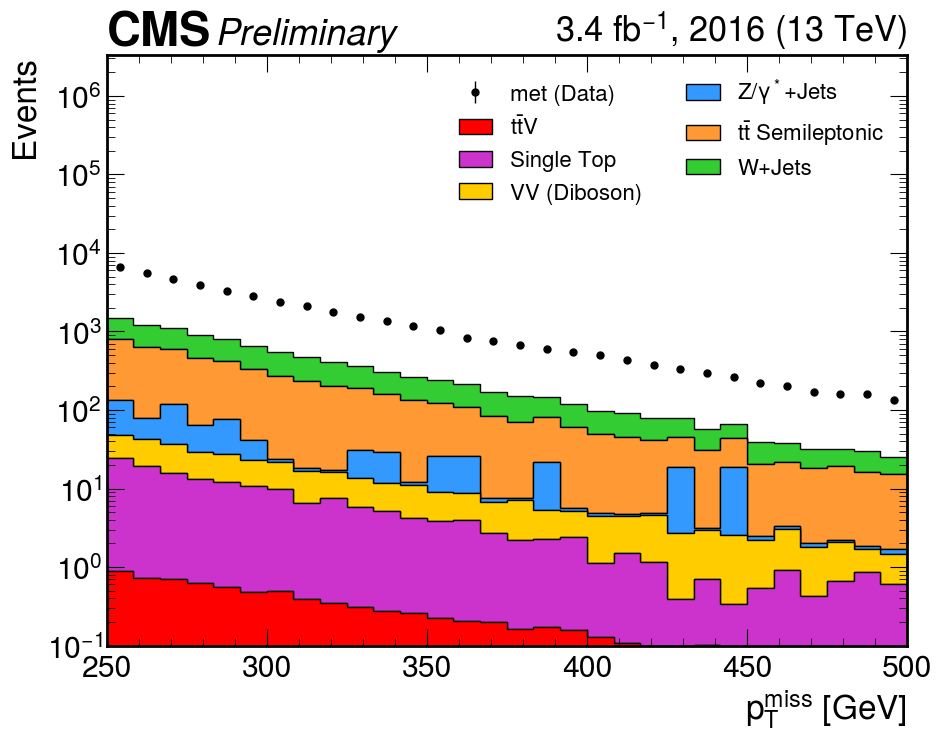

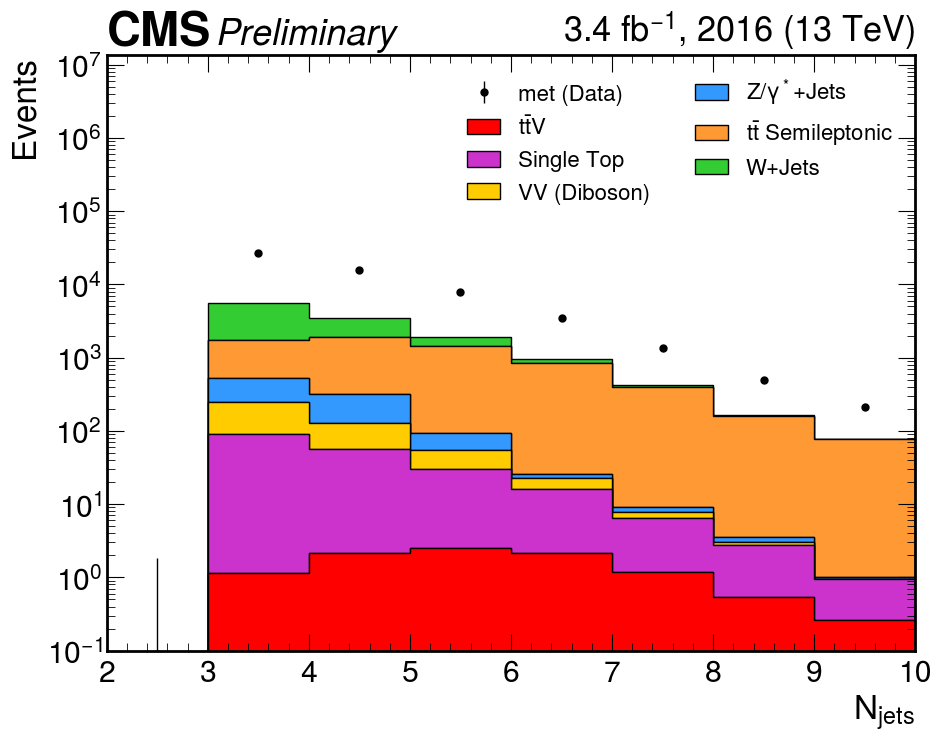

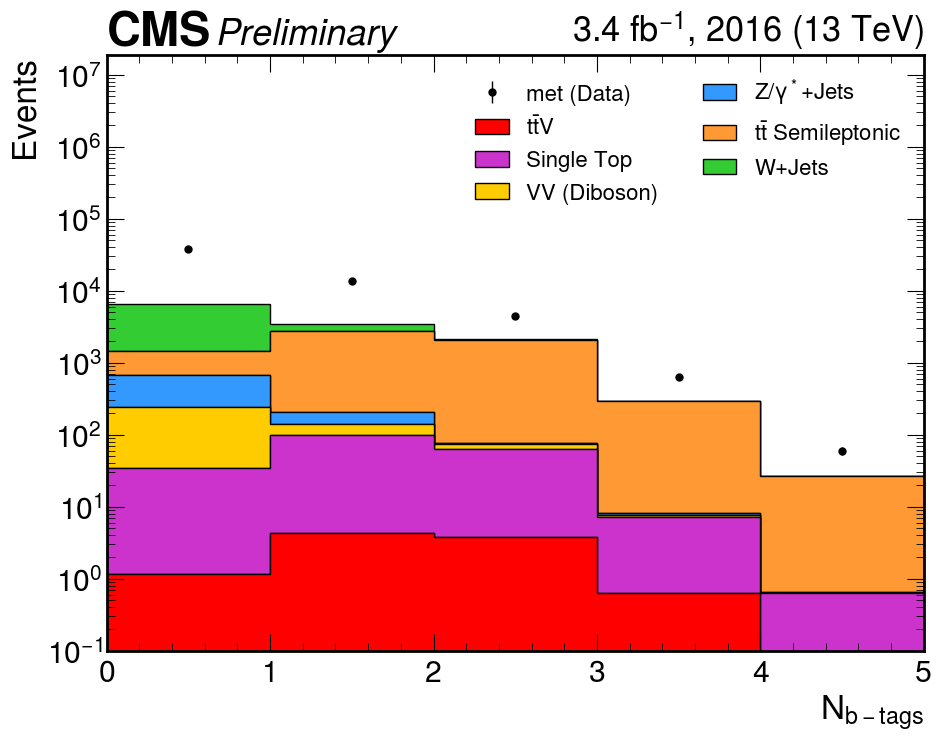

In [138]:

loaded_dfs = {}


# Full list of expected Muon datasets
datasets_AH_channel = [
    'met',           # Data
    'ttbar-semileptonic',   # Top
    'ttW', 'WW', 'ZZ', 'Zvv', 'DYJets-Zpt200',
    't-channel-top',
    't-channel-antitop',
    'WJets-HT400to600',
    'WJets-HT100to200',
    'WJets-HT200to400',
    'WJets-HT70to100'

    # WJets binned (GOOD)
]

LUM = 3400.0 ## The one that fits best is also consistent with the percentage of data used in that period.
for dataset in datasets_AH_channel:
    
    # Muon channel uses '_raw.parquet' (no electron prefix)
    path = f"output_raw/{dataset}_raw.parquet"
    
    try:
        df = pd.read_parquet(path)
        
        # Normalization
        if dataset in DATA_SL:
            df["final_weight"] = 1.0
        else:
            xsec = fileset[dataset]["metadata"]["xsec"]
            sum_w = sum_weights_map.get(dataset, 1.0)
            if sum_w == 0:
                sum_w = 1.0
            scale = (xsec * LUM) / sum_w
            
            # Use genWeight if available
            if "genWeight" in df.columns:
                df["final_weight"] = df["genWeight"] * scale
            else:
                df["final_weight"] = scale
        
        loaded_dfs[dataset] = df
        print(f" Loaded: {dataset}")
    
    except FileNotFoundError:
        # Skip missing datasets silently
        continue

# Final dictionary with loaded Muon datasets
olep_dfs_clean = loaded_dfs

# Update all_dfs globally
all_dfs = olep_dfs_clean

########################################################################
#########################################################################

if len(olep_dfs_clean) > 0:
    mi_canal = "met"
    
    #plot_grouped_stack("mT_W", r"$m_T^W$ [GeV]", (0, 200), mi_canal, log_scale=False)
    plot_grouped_stack("met", r"$p_T^{miss}$ [GeV]", (250, 500), mi_canal, log_scale=True)
    plot_grouped_stack("nJet", r"$N_{jets}$", (2, 10), mi_canal, n_bins=8, log_scale=True)
    plot_grouped_stack("nBTag", r"$N_{b-tags}$", (0, 5), mi_canal, n_bins=5, log_scale=True)

else:
    print(" No data loaded. Check if the _raw.parquet files exist.")



and with the same idea as the muon one

In [140]:

def load_data(channel="met"):
    loaded_dfs = {}
    
    datasets_to_load = [
        'met' if channel == 'met' else 'SingleMuon',
        'ttbar-semileptonic', 'ttW', 'WW', 'ZZ', 'Zvv', 
        'DYJets-Zpt200', 't-channel-top','t-channel-antitop','WJets-HT400to600','WJets-HT100to200','WJets-HT70to100','WJets-HT200to400'
    ]


    LUM = 3400.0
    
    suffix = "_raw.parquet" if channel == "met" else "_electron_raw.parquet"

    for ds in datasets_to_load:
        path = f"output_raw/{ds}{suffix}"
        try:
            df = pd.read_parquet(path)
            
            # Normalización
            if ds in DATA_SL:
                df["final_weight"] = 1.0
            else:
                if ds not in fileset: continue
                xsec = fileset[ds]["metadata"]["xsec"]
                sum_w = sum_weights_map.get(ds, 1.0) 
                if sum_w == 0: sum_w = 1.0
                
                scale = (xsec * LUM) / sum_w
                
                if "genWeight" in df.columns:
                    df["final_weight"] = df["genWeight"] * scale
                else:
                    df["final_weight"] = scale
            
            loaded_dfs[ds] = df
            
        except FileNotFoundError:
            continue
            
    return loaded_dfs



In [141]:

def signal_regions(df):

    
    if df is None or len(df) == 0: return {}
    
    pass_common = (
        (df["met"] > 250) &
        (df["min_dphi"] > 1.0) 
    )
    
    df_sr = df[pass_common]
    if len(df_sr) == 0: return {}

# Definition of the 3 Regions (Categories)   
    mask_1b_0f = (df_sr["nBTag"] == 1) & (df_sr["nForwardJets"] == 0)
    mask_1b_1f = (df_sr["nBTag"] == 1) & (df_sr["nForwardJets"] >= 1)
    mask_2b = (df_sr["nBTag"] >= 2) 
    
    return {
        "SR_1b_0f": df_sr[mask_1b_0f],
        "SR_1b_1f": df_sr[mask_1b_1f],
        "SR_2b":    df_sr[mask_2b]
    }



In [142]:

def plot_region_stack(dfs_dict, region_name, var_name, x_label, x_range, channel_label, n_bins=10):
    
    bins = np.linspace(x_range[0], x_range[1], n_bins + 1)
    
    grouped_counts = {}
    grouped_info = {}
    
    for name, df in dfs_dict.items():
        if name in DATA_SL: continue 
        
        counts, _ = np.histogram(df[var_name], bins=bins, weights=df["final_weight"])
        g_key, label, color = get_group_info(name)
        
        if g_key not in grouped_counts:
            grouped_counts[g_key] = counts
            grouped_info[g_key] = {"label": label, "color": color, "yield": np.sum(counts)}
        else:
            grouped_counts[g_key] += counts
            grouped_info[g_key]["yield"] += np.sum(counts)


    # Sort stack
    active_groups = sorted(grouped_info.keys(), key=lambda k: grouped_info[k]["yield"])
    
    mc_counts = []
    mc_colors = []
    mc_labels = []
    total_mc = np.zeros(n_bins)
    
    for g in active_groups:
        mc_counts.append(grouped_counts[g])
        mc_colors.append(grouped_info[g]["color"])
        mc_labels.append(grouped_info[g]["label"])
        total_mc += grouped_counts[g]

    # Data
    df_data = dfs_dict.get(channel_label)
    data_counts = np.zeros(n_bins)
    if df_data is not None:
        data_counts, _ = np.histogram(df_data[var_name], bins=bins)

    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    if len(mc_counts) > 0:
        hep.histplot(mc_counts, bins=bins, stack=True, histtype="fill",
                     color=mc_colors, label=mc_labels, edgecolor="black", linewidth=1, ax=ax)
    
    hep.histplot(data_counts, bins=bins, histtype="errorbar", color="black",
                 label=f"{channel_label} (Data)", yerr=True, marker='o', markersize=5, ax=ax)

    hep.cms.label("Preliminary", data=True, lumi=3.4, year=2016, ax=ax)
    
    handles, labels = ax.get_legend_handles_labels()
    by_label = OrderedDict(zip(labels[::-1], handles[::-1]))
    ax.legend(by_label.values(), by_label.keys(), fontsize=15, ncol=2, loc='upper right')
    
    ax.text(0.05, 0.93, f"{region_name}", transform=ax.transAxes, 
            fontsize=20, fontweight='bold', va='top')
    
    ax.set_xlabel(x_label, fontsize=24)
    ax.set_ylabel("Events", fontsize=24)
    ax.set_xlim(x_range)
    ax.set_yscale("log") 
    
    max_y = max(np.max(data_counts), np.max(total_mc))
    ax.set_ylim(0.1, max_y * 500) 

    plt.tight_layout()
    plt.show()



In [146]:

def run_analysis_for_channel(channel_mode):

    raw_dfs = load_data(channel_mode)
    if not raw_dfs: return
    
    regions_db = {"SR_1b_0f": {}, "SR_1b_1f": {}, "SR_2b": {}}
    for name, df in raw_dfs.items():
        sub_regions = signal_regions(df)
        for reg, df_reg in sub_regions.items():
            regions_db[reg][name] = df_reg
            
    d_label = "MET" if channel_mode == "met" else "SingleMuon"
    
    plot_region_stack(regions_db["SR_2b"], "SR 2b", "met", r"$p_T^{miss}$ [GeV]", (250, 600), d_label)
    plot_region_stack(regions_db["SR_1b_1f"], r"SR 1b $\geq$1f", "met", r"$p_T^{miss}$ [GeV]", (250, 600), d_label)
    plot_region_stack(regions_db["SR_1b_0f"], "SR 1b 0f", "met", r"$p_T^{miss}$ [GeV]", (250, 600), d_label)



/cvmfs/sft.cern.ch/lcg/views/LCG_109_swan/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


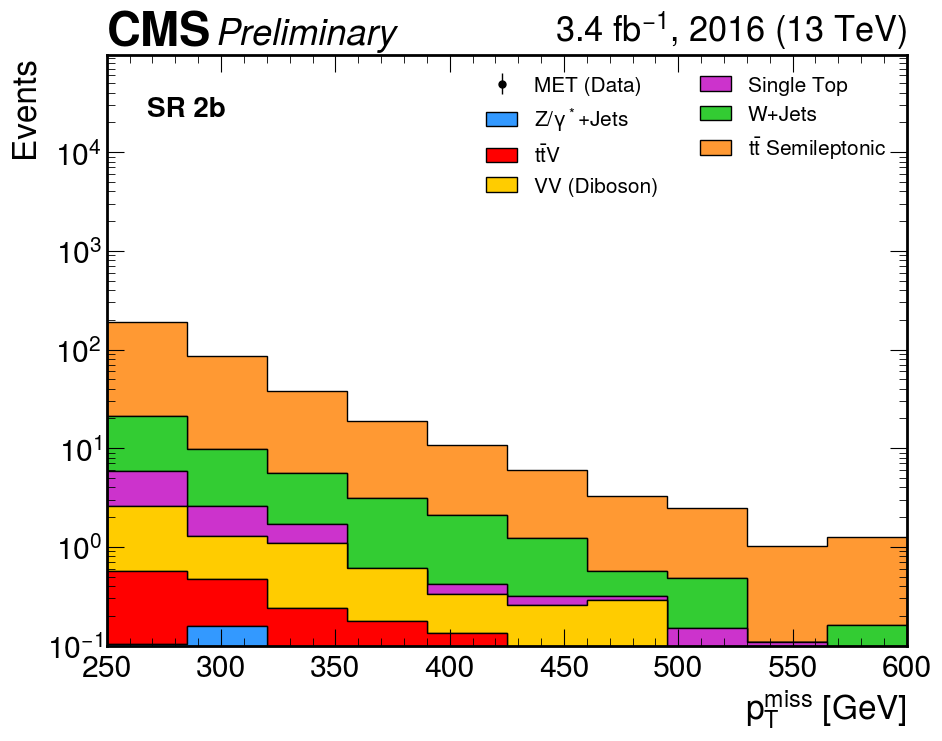

/cvmfs/sft.cern.ch/lcg/views/LCG_109_swan/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


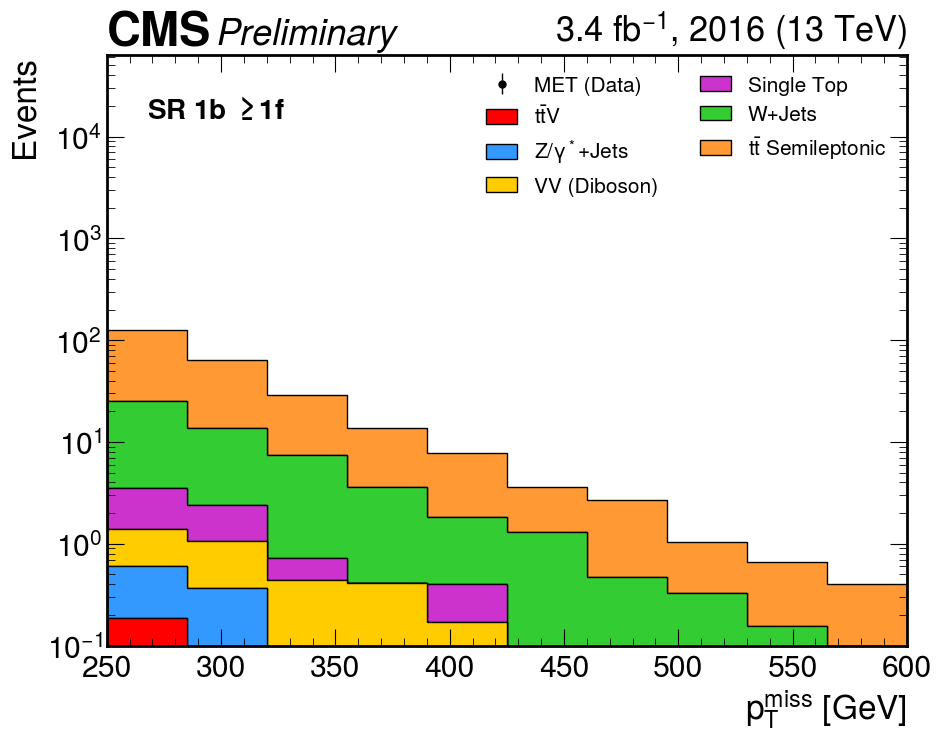

/cvmfs/sft.cern.ch/lcg/views/LCG_109_swan/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


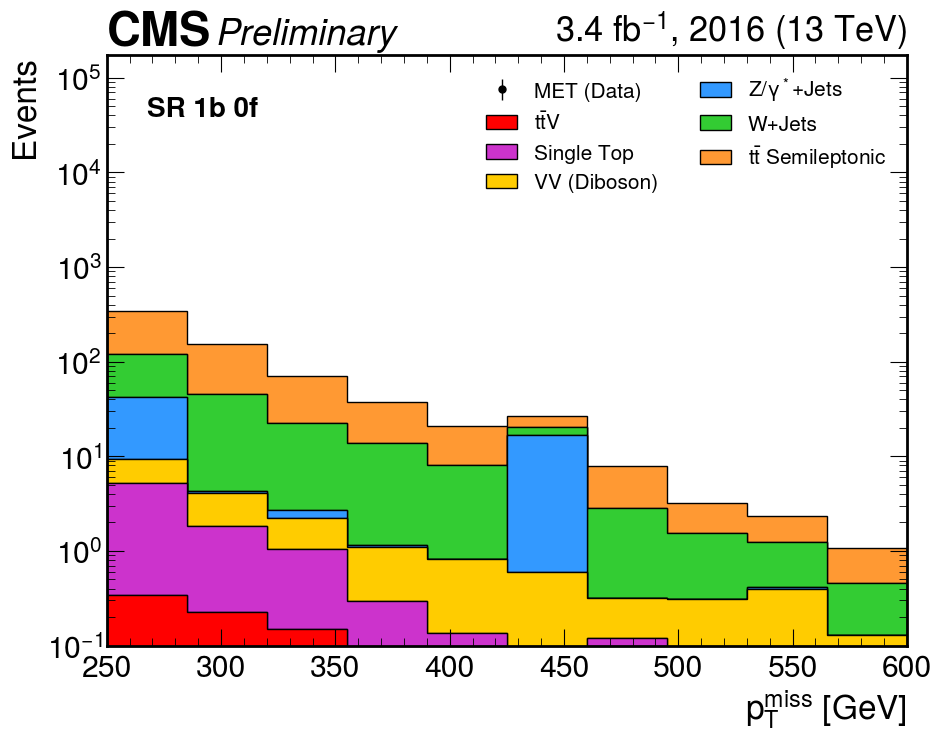

In [147]:

from collections import OrderedDict


if 'sum_weights_map' in globals():
    run_analysis_for_channel("met")
    #run_analysis_for_channel("electron")
else:
    print(" Error.")



In [151]:

def filter_cr_wlnu(df):
    """
    Control Region: CR W(lν)
    Nombres oficiales Tabla 14:
        - SL1eWR  (electrón)
        - SL1mWR  (muón)
    """
    if df is None or len(df) == 0:
        return {}

    mask = (
        (df["met"] >= 250) &
        #(df["mT"] <= 160) &
        (df["nBTag"] == 0) &
        (df["nJet"] >= 3)
    )

    df_cr = df[mask]
    if len(df_cr) == 0:
        return {}

    return {"CR_Wlnu": df_cr}



Once `plot_region_stack` was defined, the same base structure was reused to create `plot_cr_stack`. The core stacked histogram logic stays the same, but additional lines were added or modified to specialize the plot for Control Regions.

The main changes are:

* A **new function name** was created: `plot_cr_stack`.
* A new input parameter was added to handle the **control region label** (for example: `region_label`).
* The plot now includes a **region tag drawn on the figure**, added through a line like:
  `ax.text(..., region_label, ...)`
* The function was adapted to work with **Control Region–filtered datasets**, instead of general or signal regions.
* The default axis ranges and binning were tuned for control-region kinematics.

All histogram stacking, coloring, grouping, and legend logic remains the same as in the previous functions.

In [152]:

def plot_cr_stack(dfs_dict, region_label, var_name, x_label, x_range, data_label, n_bins=15):

    bins = np.linspace(x_range[0], x_range[1], n_bins + 1)
    grouped_counts = {}
    grouped_info = {}

    # A) MC
    for name, df in dfs_dict.items():
        if name in DATA_SL:
            continue

        counts, _ = np.histogram(df[var_name], bins=bins, weights=df["final_weight"])
        g_key, label, color = get_group_info(name)

        if g_key not in grouped_counts:
            grouped_counts[g_key] = counts
            grouped_info[g_key] = {"label": label, "color": color, "yield": np.sum(counts)}
        else:
            grouped_counts[g_key] += counts
            grouped_info[g_key]["yield"] += np.sum(counts)

    active_groups = sorted(grouped_info.keys(), key=lambda k: grouped_info[k]["yield"])

    mc_counts = []
    mc_colors = []
    mc_labels = []
    total_mc = np.zeros(n_bins)

    for g in active_groups:
        mc_counts.append(grouped_counts[g])
        mc_colors.append(grouped_info[g]["color"])
        mc_labels.append(grouped_info[g]["label"])
        total_mc += grouped_counts[g]

    # B) DATA
    df_data = dfs_dict.get(data_label)
    if df_data is not None:
        data_counts, _ = np.histogram(df_data[var_name], bins=bins)
    else:
        data_counts = np.zeros(n_bins)

    # === Plot ===
    fig, ax = plt.subplots(figsize=(10, 8))

    hep.histplot(mc_counts, bins=bins, stack=True, histtype="fill",
                 color=mc_colors, label=mc_labels, edgecolor="black", linewidth=1, ax=ax)

    hep.histplot(data_counts, bins=bins, histtype="errorbar", color="black",
                 label=f"{data_label} (Data)", yerr=True, marker='o', markersize=5, ax=ax)

    hep.cms.label("Preliminary", data=True, lumi=3.4, year=2016, ax=ax)

    ax.text(0.05, 0.93, region_label, transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='left')

    handles, labels = ax.get_legend_handles_labels()
    by_label = OrderedDict(zip(labels[::-1], handles[::-1]))
    ax.legend(by_label.values(), by_label.keys(), fontsize=15, ncol=2, loc='upper right')

    ax.set_xlabel(x_label, fontsize=24)
    ax.set_ylabel("Events", fontsize=24)
    ax.set_xlim(x_range)
    ax.set_yscale("log")

    max_y = max(np.max(data_counts), np.max(total_mc))
    ax.set_ylim(0.1, max_y * 500)

    plt.tight_layout()
    plt.show()





/cvmfs/sft.cern.ch/lcg/views/LCG_109_swan/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


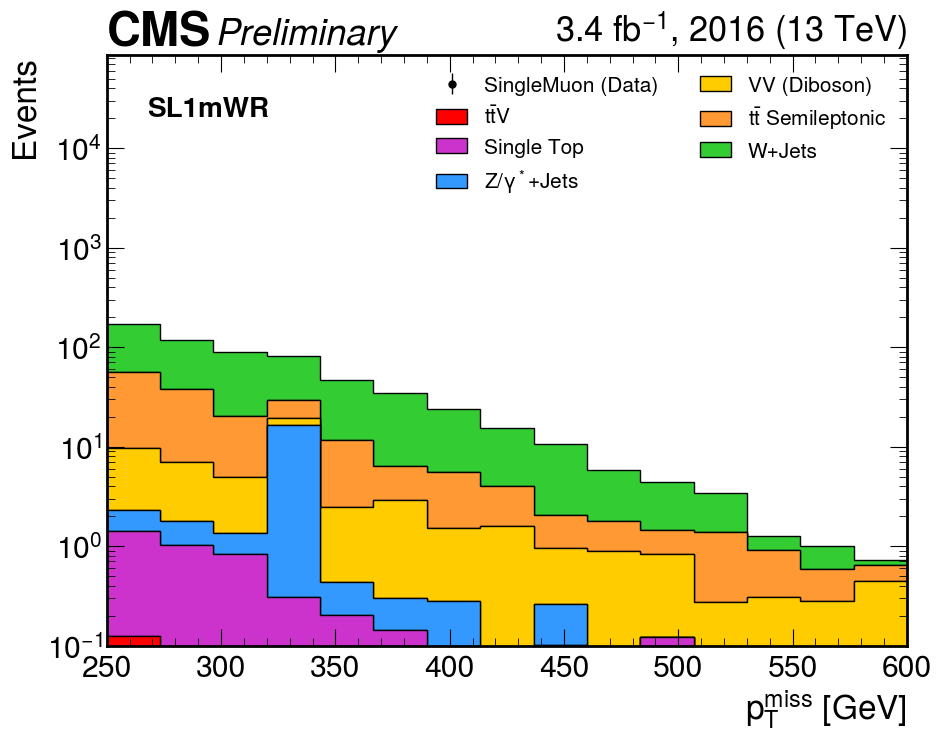

/cvmfs/sft.cern.ch/lcg/views/LCG_109_swan/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


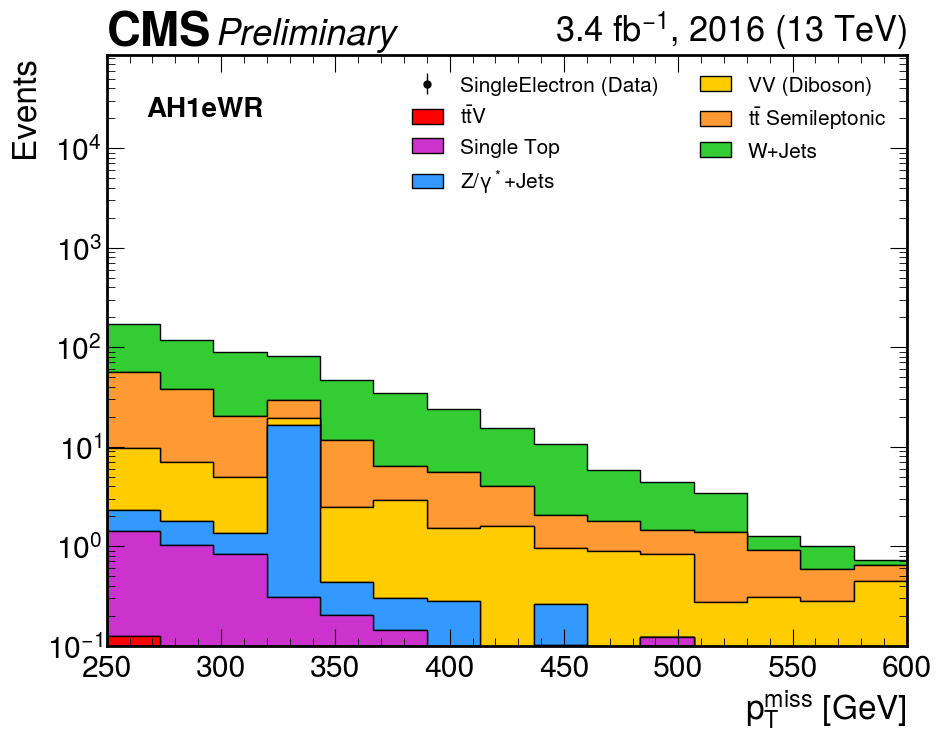

In [153]:


def run_SL(channel_mode):

    # 1. Load datasets
    raw_dfs = load_data(channel_mode)
    if not raw_dfs:
        return

    # 2. Filtrar región CR W(lν)
    cr_dict = {}
    for name, df in raw_dfs.items():
        reg = filter_cr_wlnu(df)
        if "CR_Wlnu" in reg:
            cr_dict[name] = reg["CR_Wlnu"]

    if len(cr_dict) == 0:
        print(" No events passed CR W(lν).")
        return

    # 3. Etiquetas correctas según Tabla 14
    if channel_mode == "muon":
        region_label = "SL1mWR"
        data_label = "SingleMuon"
    else:
        region_label = "AH1eWR"
        data_label = "SingleElectron"


    # plot MET
    plot_cr_stack(cr_dict, region_label, "met", r"$p_T^{miss}$ [GeV]", (250, 600), data_label, n_bins=15)

    # plot MT
    #plot_cr_stack(cr_dict, region_label, "mT_W", r"$m_T^W$ [GeV]", (160, 500), data_label, n_bins=15)


# --- RUN ---
run_SL("muon")
run_SL("electron")
